# PINNs for Schwarzschild orbits: the orbit equation is the loss (CPU)

Equatorial orbits around a non-rotating black hole, in Binet form ($u = M/r$ as a
function of the orbital angle $\varphi$):

- light: $u'' + u = 3u^2$
- a massive body: $u'' + u = 1/p + 3f\,u^2$, where $f = 1$ is Einstein and $f = 0$ is Newton

Three experiments, all physics-informed (the networks learn from the equation's
residual, not from solved orbits):

1. **One ray, from the equation alone.** How close to the photon sphere
   ($b \to b_\text{crit} = 3\sqrt3\,M$) can a PINN get the deflection right? One network
   over the whole ray against marching window by window.
2. **Every ray at once.** One network $u(\varphi, b)$ for $b \in [5.25, 30]$, a deflection
   surrogate trained on no data, against the data-trained one (1.4%).
3. **Weighing relativity from an orbit.** From a few noisy positions of a star, recover
   $p$ and $f$: can it tell Einstein from Newton, and how does it compare with the
   classical shooting fit?

**Before running:** Settings -> Accelerator -> **None** (CPU; the networks are tiny,
and four jobs on four cores beat one GPU), Internet **on**. About 45 minutes.

In [1]:
# The repo goes to /tmp, so the notebook's output holds only the results.
import os, shutil, sys
REPO_URL = "https://github.com/amark-23/black-hole-ml.git"
REPO = "/tmp/black-hole-ml"
if os.path.exists(REPO):
    shutil.rmtree(REPO)
!git clone -q --depth 1 {REPO_URL} {REPO}
!pip -q install -e {REPO}
sys.path.insert(0, os.path.join(REPO, "ml"))

import json, math, time
import numpy as np
import torch
from IPython.display import Image, display
from bhml import pinn as P

WORKERS = os.cpu_count()
print("cores:", WORKERS, "| torch", torch.__version__)
OUT = "/kaggle/working/pinn_results"
os.makedirs(OUT, exist_ok=True)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for bhml (pyproject.toml) ... done
cores: 4 | torch 2.10.0+cpu


## Settings

In [2]:
FORWARD = dict(P.FORWARD)    # tanh MLP 32x3, Adam 3000 + L-BFGS 1000 per window, 1 rad windows
PARAM = dict(P.PARAM)        # u(phi, b): tanh MLP 64x4, Adam 10000 + L-BFGS 2000, b in [5.25, 30]
INVERSE = dict(P.INVERSE)    # u(phi): tanh MLP 64x4, Adam 3000 + L-BFGS 1000, p and f trainable

GAPS = [10, 3, 1, 0.3, 0.1, 0.03, 0.01, 1e-3, 1e-4]   # b - b_crit for the single-ray study
ENCODINGS = ["log", "lin"]                            # how the parametric network sees b
NOISES = [0.001, 0.003, 0.01, 0.03, 0.1]              # noise std / mean u
N_OBS = [10, 30, 100]                                  # observed positions (at 1% noise)
N_ORBITS = [1, 2, 3]                                   # turns observed (at 1% noise, 30 points)
SEEDS = [0, 1, 2, 3]                                   # noise draws per setting
ORBIT = dict(p=20.0, e=0.5)                            # periapsis 13.3 M, apoapsis 40 M

## Run everything

All jobs go into one pool, the longest first, one core each.

In [3]:
jobs = [(P.param_job, dict(cfg=dict(PARAM, enc=e))) for e in ENCODINGS]
jobs += [(P.forward_job, dict(b=P.B_CRIT + g, mode=m, cfg=FORWARD))
         for g in GAPS for m in ("march", "single")]
inv = [dict(ORBIT, f=f, noise=n, seed=s) for f in (1.0, 0.0) for n in NOISES for s in SEEDS]
inv += [dict(ORBIT, f=1.0, noise=0.01, n_obs=k, seed=s) for k in N_OBS if k != 30 for s in SEEDS]
inv += [dict(ORBIT, f=1.0, noise=0.01, n_orbits=k, seed=s) for k in N_ORBITS if k != 3 for s in SEEDS]
jobs += [(P.inverse_job, dict(kw, cfg=INVERSE)) for kw in inv]
print(len(jobs), "jobs on", WORKERS, "cores")
t0 = time.time()
res = P.run_parallel(P.call, jobs, WORKERS, label="jobs")
print(f"all done in {(time.time() - t0) / 60:.1f} min")
param_res = dict(zip(ENCODINGS, res[:len(ENCODINGS)]))
fwd_res = res[len(ENCODINGS):len(ENCODINGS) + 2 * len(GAPS)]
inv_res = res[len(ENCODINGS) + 2 * len(GAPS):]

76 jobs on 4 cores
  jobs: 1/76 done, 83s
  jobs: 2/76 done, 154s
  jobs: 3/76 done, 227s
  jobs: 4/76 done, 233s
  jobs: 5/76 done, 308s
  jobs: 6/76 done, 453s
  jobs: 7/76 done, 528s
  jobs: 8/76 done, 539s
  jobs: 9/76 done, 618s
  jobs: 10/76 done, 839s
  jobs: 11/76 done, 922s
  jobs: 12/76 done, 925s
  jobs: 13/76 done, 970s
  jobs: 14/76 done, 1006s
  jobs: 15/76 done, 1016s
  jobs: 16/76 done, 1086s
  jobs: 17/76 done, 1162s
  jobs: 18/76 done, 1298s
  jobs: 19/76 done, 1373s
  jobs: 20/76 done, 1520s
  jobs: 21/76 done, 1548s
  jobs: 22/76 done, 1674s
  jobs: 23/76 done, 1776s
  jobs: 24/76 done, 1931s
  jobs: 25/76 done, 1963s
  jobs: 26/76 done, 2092s
  jobs: 27/76 done, 2184s
  jobs: 28/76 done, 2343s
  jobs: 29/76 done, 2344s
  jobs: 30/76 done, 2504s
  jobs: 31/76 done, 2608s
  jobs: 32/76 done, 2751s
  jobs: 33/76 done, 2756s
  jobs: 34/76 done, 2882s
  jobs: 35/76 done, 2987s
  jobs: 36/76 done, 3157s
  jobs: 37/76 done, 3159s
  jobs: 38/76 done, 3288s
  jobs: 39/76 do

## 1. One ray: how close to the photon sphere

Relative error of the deflection, with the turning point read off where $u'$ first
turns negative. "single" is one network over a domain just long enough to hold the
turning point (it is given the answer's length); "march" goes one radian at a time
from where the last window ended and needs nothing.

b - b_crit    exact | single: error   time | march: error windows   time
     1e+01    0.331 |      3.25e-05    83s |     2.70e-05       2   154s
     3e+00    0.821 |      4.80e-05    80s |     3.35e-07       2   144s
     1e+00    1.549 |      2.04e-04    75s |     1.90e-05       3   226s
     3e-01    2.565 |      1.57e-05    75s |     3.17e-06       3   231s
     1e-01    3.594 |      6.84e-05    79s |     6.15e-05       4   311s
     3e-02    4.769 |      5.66e-03    82s |     9.55e-05       4   306s
     1e-02    5.859 |      3.81e-02    81s |     2.42e-04       5   376s
     1e-03    8.156 |           nan    80s |     2.17e-03       6   404s
     1e-04   10.458 |      1.72e-01    76s |     1.61e-02       7   531s


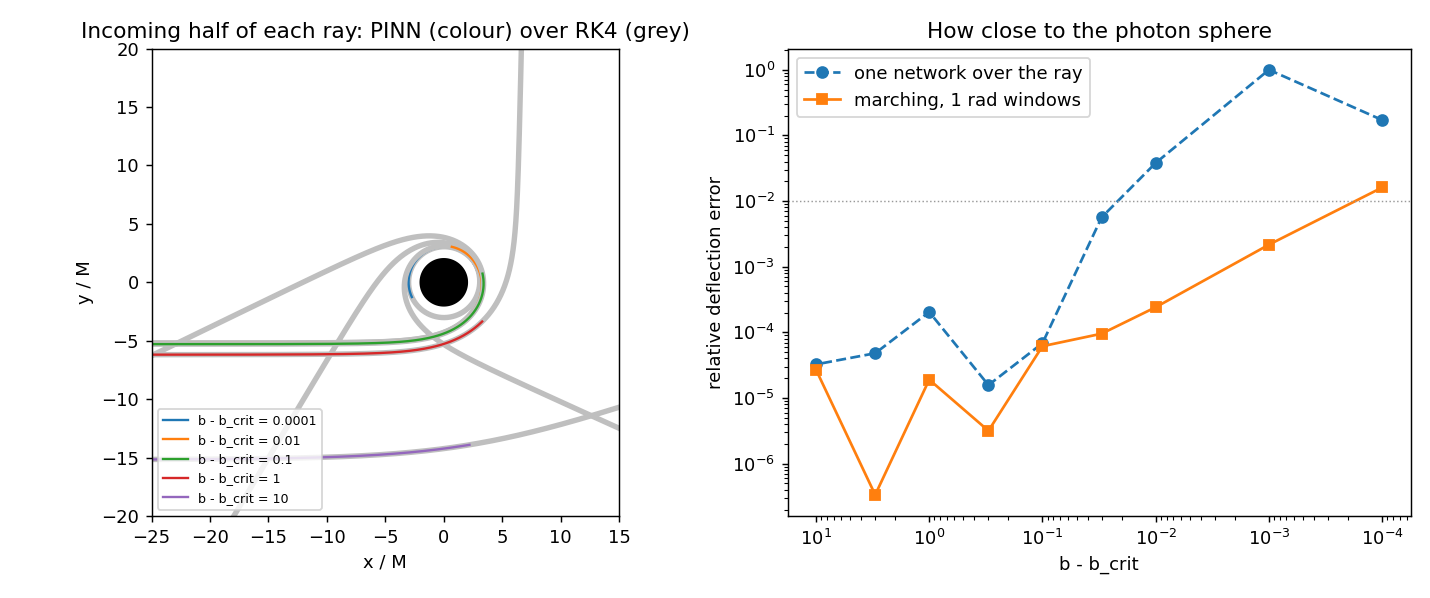

In [4]:
print(f"{'b - b_crit':>10s} {'exact':>8s} | {'single: error':>13s} {'time':>6s} | {'march: error':>12s} {'windows':>7s} {'time':>6s}")
for g in GAPS:
    s = next(r for r in fwd_res if r["mode"] == "single" and abs(r["b"] - P.B_CRIT - g) < 1e-12)
    m = next(r for r in fwd_res if r["mode"] == "march" and abs(r["b"] - P.B_CRIT - g) < 1e-12)
    print(f"{g:10.0e} {m['exact']:8.3f} | {s['rel_err']:13.2e} {s['time']:5.0f}s | {m['rel_err']:12.2e} {m['n_windows']:7d} {m['time']:5.0f}s")
P.plot_forward(fwd_res, f"{OUT}/pinn_forward.png")
display(Image(f"{OUT}/pinn_forward.png"))

## 2. Every ray at once: u(phi, b)

One network, physics only, evaluated on 200 values of $b$ against the exact deflection.

log: relative L2 0.58%, worst 1.40%, no turning point for 0 b, final loss 1.52e-07, trained in 15.9 min
   b in [5.20, 5.5): mean error 0.41%
   b in [5.50, 7): mean error 0.08%
   b in [7.00, 12): mean error 0.05%
   b in [12.00, 30.01): mean error 0.03%
lin: relative L2 10.76%, worst 20.59%, no turning point for 0 b, final loss 2.62e-07, trained in 16.7 min
   b in [5.20, 5.5): mean error 8.98%
   b in [5.50, 7): mean error 0.82%
   b in [7.00, 12): mean error 0.09%
   b in [12.00, 30.01): mean error 0.08%


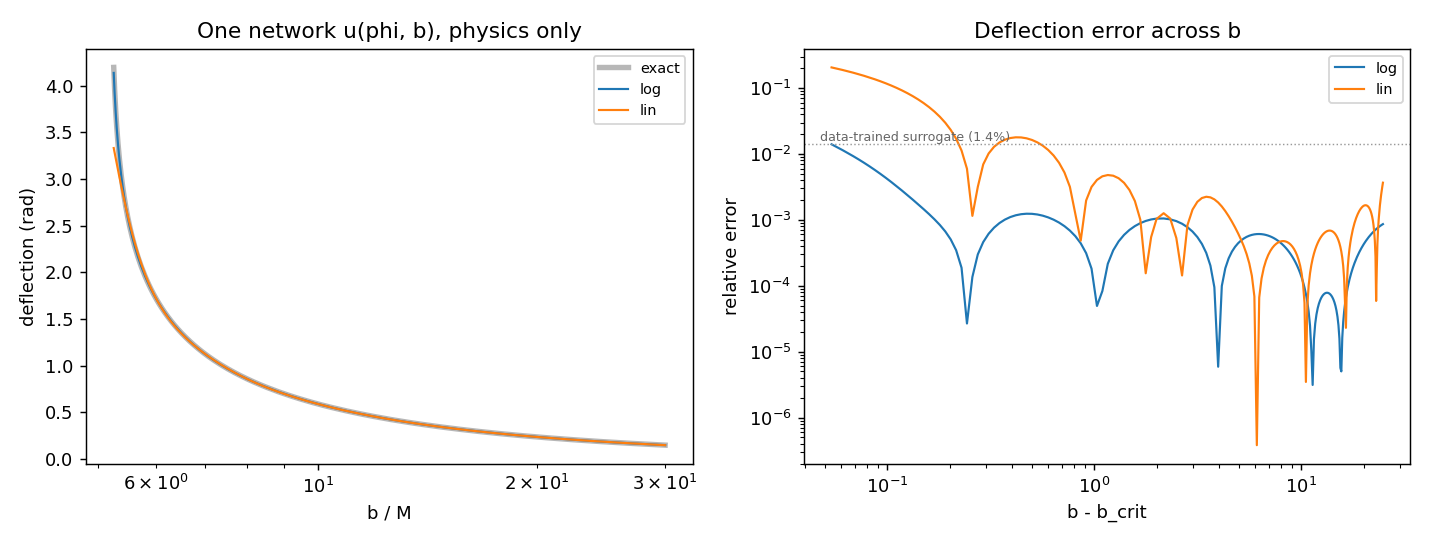

In [5]:
for name, r in param_res.items():
    print(f"{name}: relative L2 {100 * r['rel_l2']:.2f}%, worst {100 * r['max_rel']:.2f}%, "
          f"no turning point for {r['n_nan']} b, final loss {r['loss']:.2e}, trained in {r['train_time'] / 60:.1f} min")
    b, pred, ex = map(np.array, (r["b"], r["pred"], r["exact"]))
    for lo, hi in ((P.B_CRIT, 5.5), (5.5, 7), (7, 12), (12, 30.01)):
        s = (b >= lo) & (b < hi)
        print(f"   b in [{lo:.2f}, {hi:g}): mean error {100 * np.nanmean(abs(pred[s] - ex[s]) / ex[s]):.2f}%")
P.plot_param(param_res, f"{OUT}/pinn_parametric.png")
display(Image(f"{OUT}/pinn_parametric.png"))

## 3. Weighing relativity from an orbit

Orbit with $p = 20$, $e = 0.5$, observed at random angles over its turns, Gaussian
noise on $u$. The PINN learns the orbit and $(p, f)$ together; the shooting fit
integrates the ODE and fits its initial conditions, $p$ and $f$ by least squares.
Mean and spread over the noise draws.

    noise f true |          PINN f   p err |      shooting f   p err
    0.001      0 |  -0.000 ± 0.000   0.02% |  -0.000 ± 0.001   0.01%
    0.003      0 |  -0.001 ± 0.001   0.05% |  -0.000 ± 0.002   0.04%
     0.01      0 |  -0.002 ± 0.004   0.19% |  -0.000 ± 0.005   0.13%
     0.03      0 |  -0.006 ± 0.013   0.55% |  -0.000 ± 0.016   0.40%
      0.1      0 |  -0.015 ± 0.044   1.84% |   0.002 ± 0.056   1.31%
    0.001      1 |   0.999 ± 0.000   0.03% |   0.999 ± 0.000   0.03%
    0.003      1 |   0.997 ± 0.001   0.08% |   0.997 ± 0.001   0.08%
     0.01      1 |   0.991 ± 0.004   0.26% |   0.991 ± 0.003   0.28%
     0.03      1 |   0.974 ± 0.012   0.78% |   0.974 ± 0.008   0.83%
      0.1      1 |   0.906 ± 0.054   2.65% |   0.913 ± 0.022   2.74%

    n_obs f true |          PINN f   p err |      shooting f   p err
       10      1 |   0.997 ± 0.009   0.18% |   0.999 ± 0.009   0.22%
       30      1 |   0.991 ± 0.004   0.26% |   0.991 ± 0.003   0.28%
      100      1 |   0.997 ± 0.00

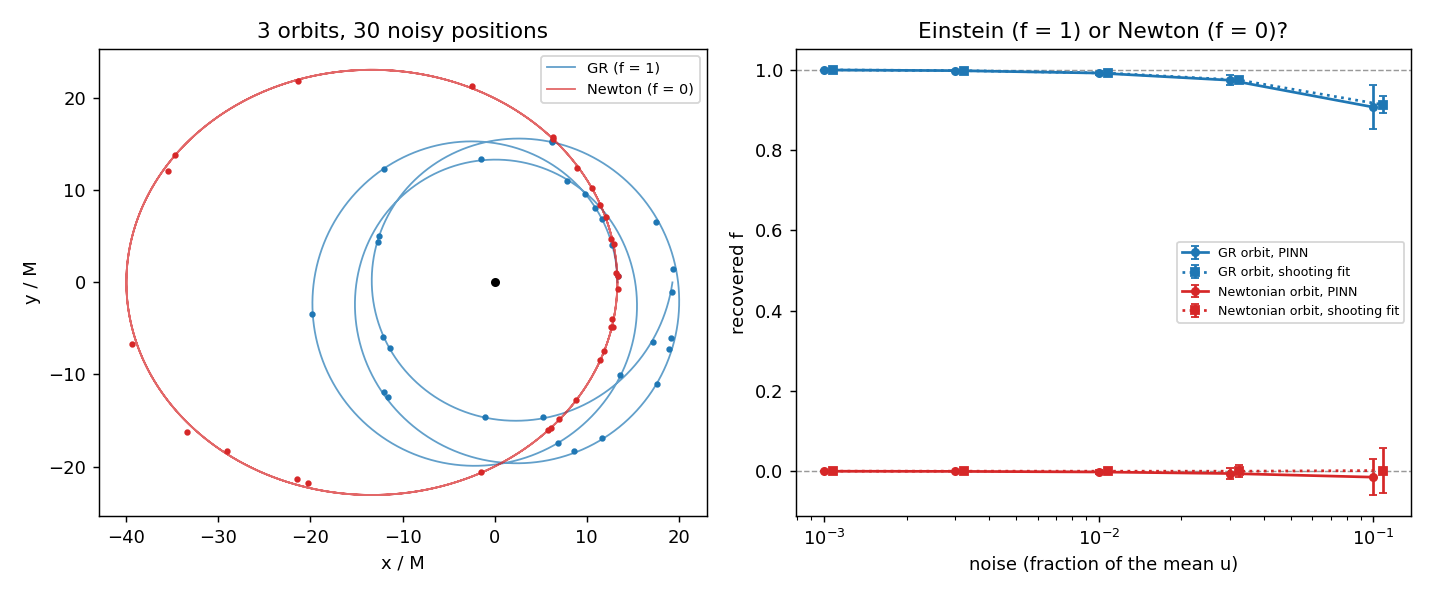

In [6]:
def show(rows, by):
    print(f"{by:>9s} {'f true':>6s} | {'PINN f':>15s} {'p err':>7s} | {'shooting f':>15s} {'p err':>7s}")
    for r in rows:
        a, s = r["pinn"], r["shooting"]
        print(f"{r[by]:9g} {r['f_true']:6g} | {a['f_mean']:7.3f} ± {a['f_std']:5.3f} {100 * a['p_err']:6.2f}% | "
              f"{s['f_mean']:7.3f} ± {s['f_std']:5.3f} {100 * s['p_err']:6.2f}%")

base = [r for r in inv_res if r["n_obs"] == 30 and r["n_orbits"] == 3]
by_noise = P.summarize_inverse(base, "noise")
by_obs = P.summarize_inverse([r for r in inv_res if r["f"] == 1.0 and r["noise"] == 0.01 and r["n_orbits"] == 3], "n_obs")
by_orbits = P.summarize_inverse([r for r in inv_res if r["f"] == 1.0 and r["noise"] == 0.01 and r["n_obs"] == 30], "n_orbits")
show(by_noise, "noise"); print()
show(by_obs, "n_obs"); print()
show(by_orbits, "n_orbits")
print("\nPINN fit time:", f"{np.mean([r['pinn']['time'] for r in inv_res]):.0f}s;",
      "shooting fit:", f"{np.mean([r['shooting']['time'] for r in inv_res]):.1f}s")
P.plot_inverse(P.make_orbit(**ORBIT, f=1.0, noise=0.01), P.make_orbit(**ORBIT, f=0.0, noise=0.01),
               {"GR orbit": [r for r in by_noise if r["f_true"] == 1.0],
                "Newtonian orbit": [r for r in by_noise if r["f_true"] == 0.0]},
               f"{OUT}/pinn_inverse.png")
display(Image(f"{OUT}/pinn_inverse.png"))

In [7]:
for name, r in param_res.items():
    torch.save({k: torch.tensor(v) for k, v in r.pop("state").items()}, f"{OUT}/param_{name}.pt")
results = dict(forward=fwd_res, param=param_res, inverse=inv_res,
               summary=dict(noise=by_noise, n_obs=by_obs, n_orbits=by_orbits),
               cfg=dict(forward=FORWARD, param=PARAM, inverse=INVERSE, orbit=ORBIT))
json.dump(results, open(f"{OUT}/results.json", "w"), indent=1)
print("saved to", OUT, ":", sorted(os.listdir(OUT)))

saved to /kaggle/working/pinn_results : ['param_lin.pt', 'param_log.pt', 'pinn_forward.png', 'pinn_inverse.png', 'pinn_parametric.png', 'results.json']
